In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
import seaborn as sns
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')

In [9]:
# create a connection of database
conn=sqlite3.connect('inventory.db')

# loading dataset 
df=pd.read_sql_query("select * from vendor_sales_summary",conn) 
df.head() 

,False,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesDollars,TotalSalesQuantity,TotalSalesPrice,TotalTax,FreightCost,Gross_profit,Profit_margin,StockTurnOver
0,0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,5101919.51,142049.0,672819.31,260999.20,68601.68,1290667.91,25.297693,1.021338
1,1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,4819073.49,160247.0,561512.37,294438.66,144929.24,1015032.27,21.062810,1.023657
2,2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,4538120.60,187140.0,461140.15,343854.07,123780.22,1119816.92,24.675786,1.001427
3,3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,4475972.88,200412.0,420050.01,368242.80,257032.07,1214774.94,27.139908,1.006337
4,4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,4223107.62,135838.0,545778.28,249587.83,257032.07,1199901.61,28.412764,1.016718


## EDA-Exploratory Data Analysis
In this phase we will analyze the resultant table to gain the insights into the distribution of each columns.This is identify the data pattern,identify anomalies,ensure data quality for furthur analysis

In [10]:
# using T we can take the transpose of the table
df.drop(columns=['False'],inplace=True)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,1.065065e+04,18753.519148,2.000000e+00,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,1.803923e+04,12662.187074,5.800000e+01,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,2.438530e+01,109.269375,3.600000e-01,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,3.564367e+01,148.246016,4.900000e-01,10.990000,15.990000,28.990000,7.499990e+03
Volume,10692.0,8.473605e+02,664.309212,5.000000e+01,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3.140887e+03,11095.086769,1.000000e+00,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,3.010669e+04,123067.799627,7.100000e-01,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesDollars,10692.0,4.223907e+04,167655.265984,0.000000e+00,729.220000,5298.045000,28396.915000,5.101920e+06
TotalSalesQuantity,10692.0,3.077482e+03,10952.851391,0.000000e+00,33.000000,261.000000,1929.250000,3.349390e+05
TotalSalesPrice,10692.0,1.879378e+04,44952.773386,0.000000e+00,289.710000,2857.800000,16059.562500,6.728193e+05


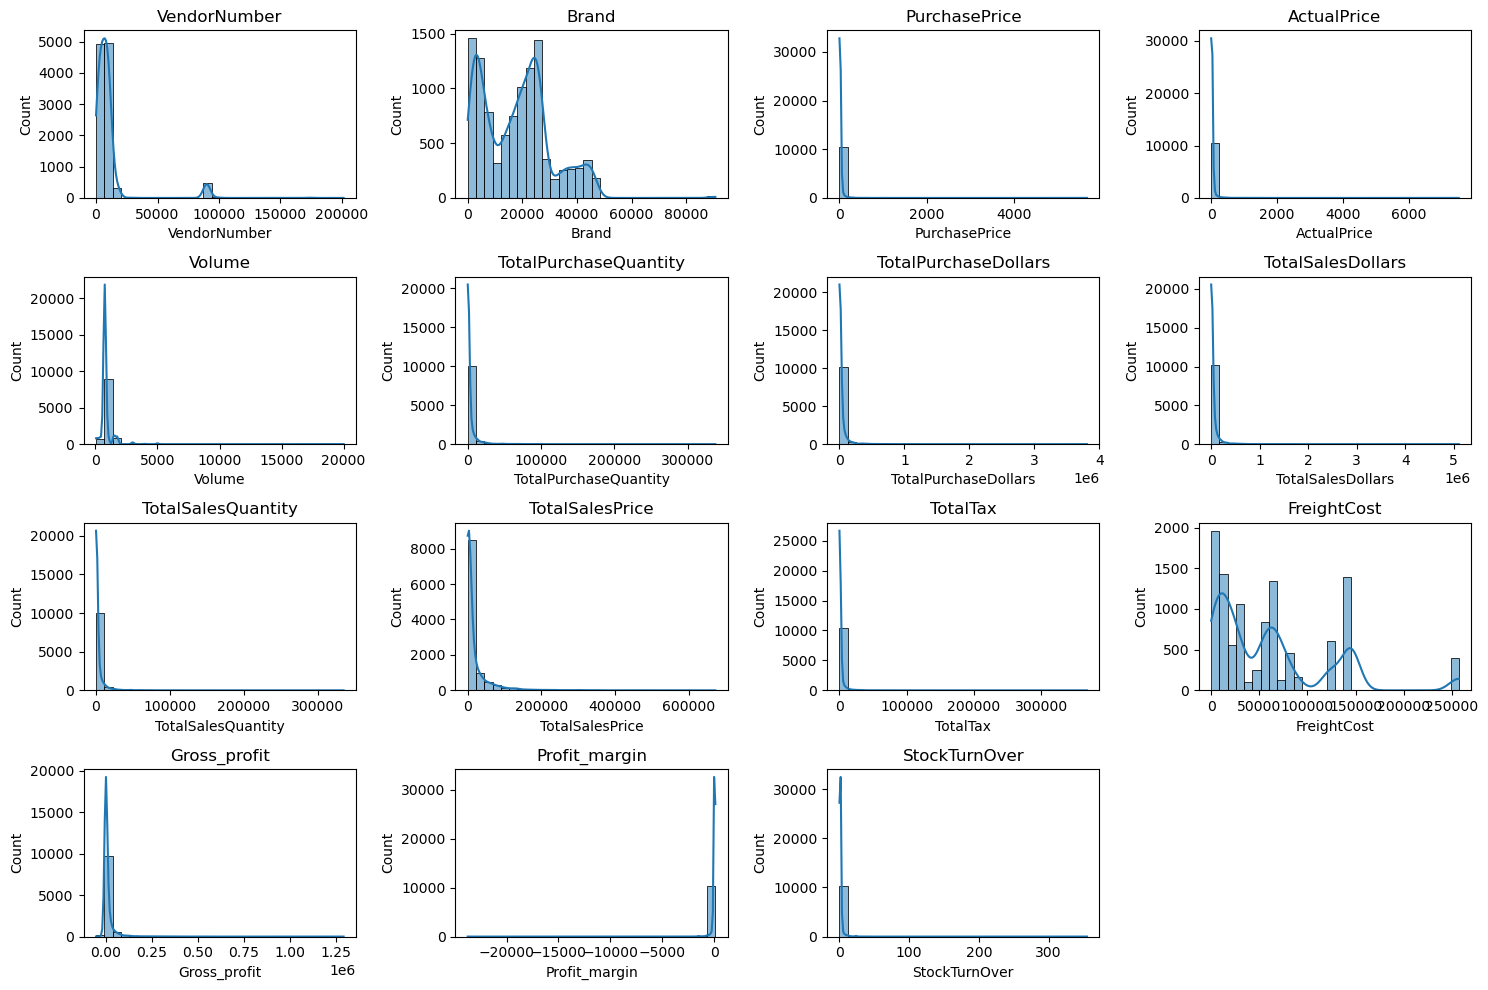

In [11]:
# distribution plots for numerical columns
num_columns=df.select_dtypes(include=np.number).columns
plt.figure(figsize=(15,10))
for i,col in enumerate(num_columns):
      plt.subplot(4,4,i+1) #adjust grid layout as needed
      sns.histplot(df[col],kde=True,bins=30) #kde is stands for "kernal density estimate" used for smooth curve on chart
      plt.title(col)
plt.tight_layout() #to maintain a specific distance between the charts 
plt.show()  

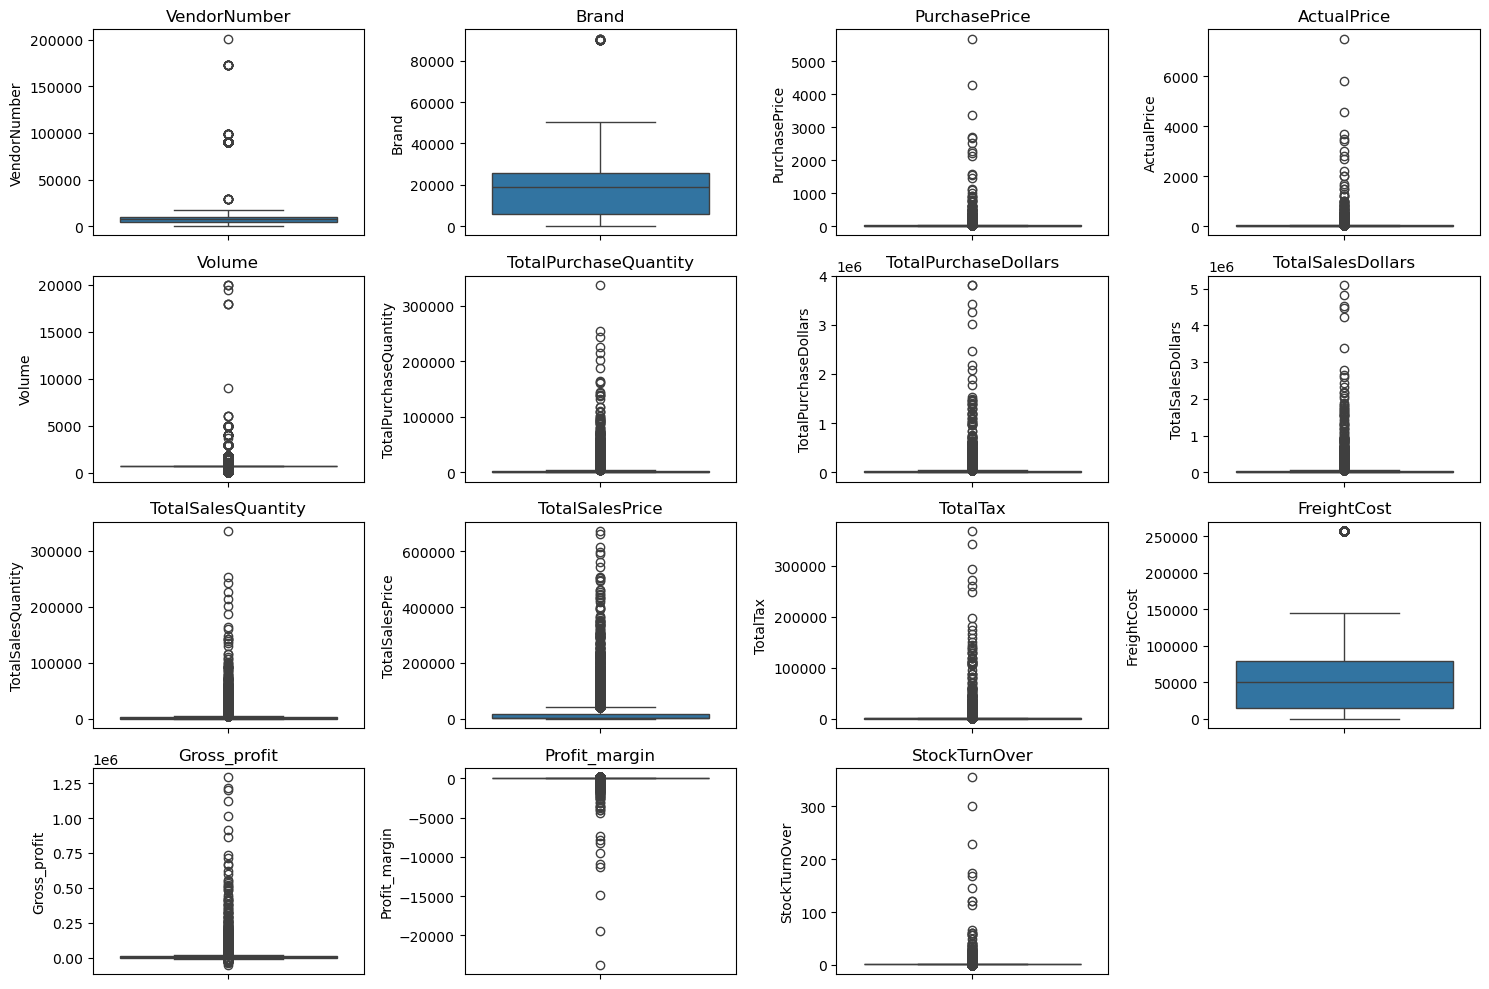

In [12]:
# outliers detection using boxplots
plt.figure(figsize=(15,10))
for i,col in enumerate(num_columns):
    plt.subplot(4,4,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout() 
plt.show() 

In [13]:
# let's filter the data by removing inconsistancy 
df=pd.read_sql_query("""select * from vendor_sales_summary where Gross_profit>0 and Profit_margin>0 and TotalSalesQuantity>0""",conn)
df

,False,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesDollars,TotalSalesQuantity,TotalSalesPrice,TotalTax,FreightCost,Gross_profit,Profit_margin,StockTurnOver
0,0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,5101919.51,142049.0,672819.31,260999.20,68601.68,1290667.91,25.297693,1.021338
1,1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,4819073.49,160247.0,561512.37,294438.66,144929.24,1015032.27,21.062810,1.023657
2,2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,4538120.60,187140.0,461140.15,343854.07,123780.22,1119816.92,24.675786,1.001427
3,3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,4475972.88,200412.0,420050.01,368242.80,257032.07,1214774.94,27.139908,1.006337
4,4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,4223107.62,135838.0,545778.28,249587.83,257032.07,1199901.61,28.412764,1.016718
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8559,10687,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,15.95,5.0,10.96,0.55,27100.41,13.31,83.448276,0.400000
8560,10688,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,65.66,134.0,1.47,7.04,50293.62,63.32,96.436186,0.044776
8561,10689,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,1.98,2.0,0.99,0.10,14069.87,0.50,25.252525,1.000000
8562,10690,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,143.28,72.0,77.61,15.12,257032.07,141.81,98.974037,0.013889


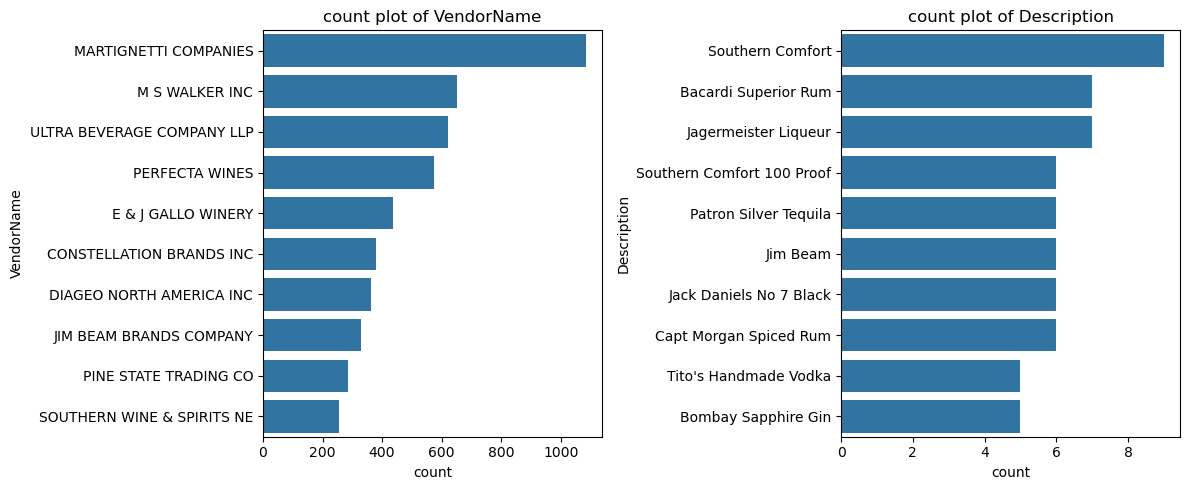

In [14]:
# distribution plots for numerical columns
categorical_col=["VendorName","Description"]
plt.figure(figsize=(12,5))

for i,col in enumerate(categorical_col):
      plt.subplot(1,2,i+1) #adjust grid layout as needed
      sns.countplot(y=df[col],order=df[col].value_counts().index[:10]) # take top 10 values just 
      plt.title(f"count plot of {col}")
plt.tight_layout() #to maintain a specific distance between the charts 
plt.show()  

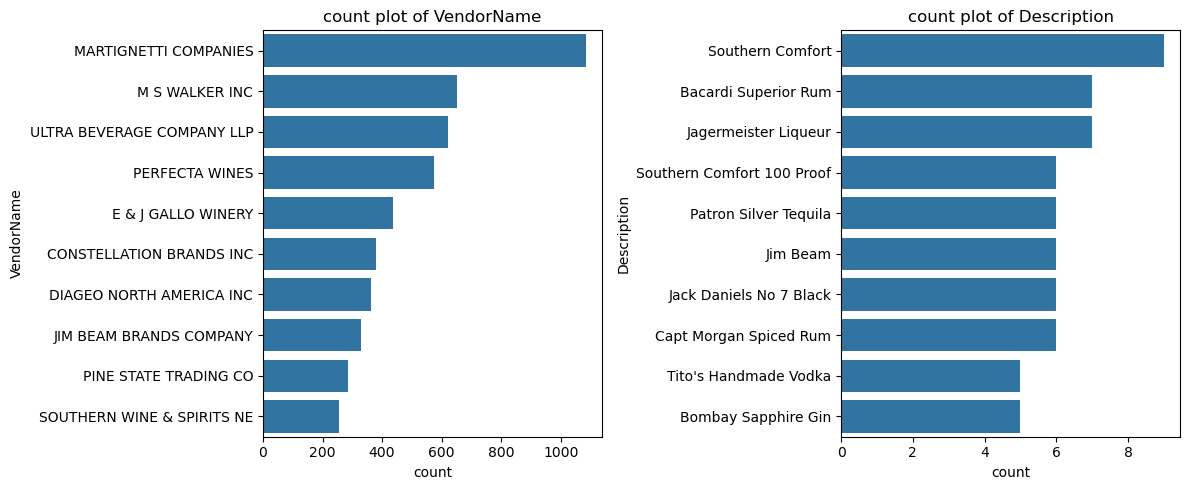

In [15]:
# distribution plots for numerical columns
categorical_col=["VendorName","Description"]
plt.figure(figsize=(12,5))

for i,col in enumerate(categorical_col):
      plt.subplot(1,2,i+1) #adjust grid layout as needed
      sns.countplot(y=df[col],order=df[col].value_counts().index[:10]) # take top 10 values just 
      plt.title(f"count plot of {col}")
plt.tight_layout() #to maintain a specific distance between the charts 
plt.show()  

Data Analysis
Identify the brand that needs promotional or price adjustment which exibits lower sales performance but higher margin 

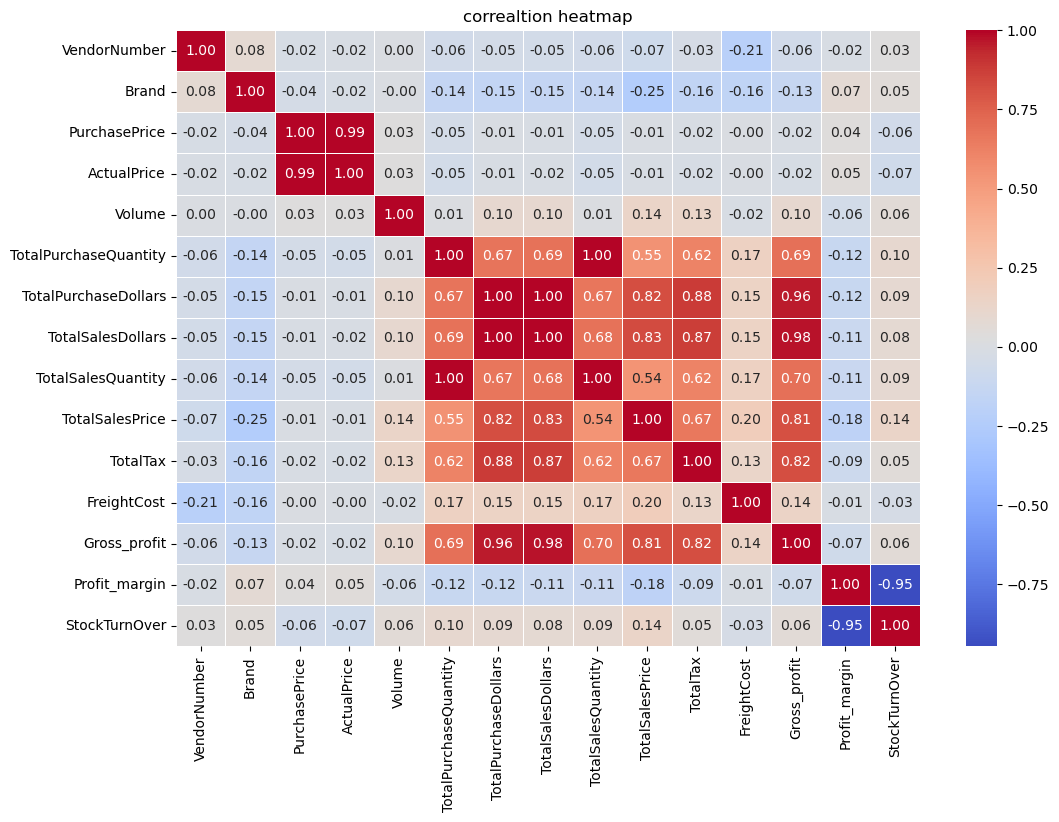

In [16]:
# correaltion heatmap
plt.figure(figsize=(12,8))
corr_matrix=df[num_columns].corr()
sns.heatmap(corr_matrix,annot=True,fmt=".2f",cmap="coolwarm",linewidth=0.5)
plt.title("correaltion heatmap")
plt.show()

In [17]:
brand_performance=df.groupby("Description").agg({
    "TotalSalesDollars":'sum',
    "Profit_margin":'mean'}).reset_index()
brand_performance

,Description,TotalSalesDollars,Profit_margin
0,(RI) 1,21519.09,18.060661
1,.nparalleled Svgn Blanc,1094.63,29.978166
2,10 Span Cab Svgn CC,2703.89,20.937612
3,10 Span Chard CC,3325.56,27.806445
4,10 Span Pnt Gris Monterey Cy,2082.22,32.226182
...,...,...,...
7702,Zorvino Vyds Sangiovese,10579.03,29.525675
7703,Zuccardi Q Malbec,1639.18,23.981503
7704,Zum Rsl,10857.34,32.675038
7705,Zwack Liqueur,227.88,16.653502


In [18]:
low_sales_threshold=brand_performance['TotalSalesDollars'].quantile(0.15)
high_profit_margin=brand_performance['Profit_margin'].quantile(0.85)

In [19]:
low_sales_threshold

np.float64(560.299)

In [20]:
high_profit_margin

np.float64(64.97017552750113)

### Brand for promotional and pricing adjustments

In [21]:
# filter brand which has low sales and high profit
target_brand=brand_performance[(brand_performance['TotalSalesDollars']<=low_sales_threshold) & 
               (brand_performance['Profit_margin']<=high_profit_margin)]
print("brand of low sales and hogh profit margin")
display(target_brand.sort_values(by='TotalSalesDollars')) 

brand of low sales and hogh profit margin


,Description,TotalSalesDollars,Profit_margin
6942,Terruzzi & Puthod Vernaccia,4.99,32.464930
2897,Firefly Ridge Chard,5.79,31.088083
148,Albero Sparkling Wh Organic,5.79,28.497409
6488,Smirnoff Light Strawberry,5.94,50.168350
178,Allen's Blue Curacao Liqueur,5.99,20.033389
...,...,...,...
1796,Ch de Pez 10 St Estephe Brdx,558.87,45.046254
5489,Pepperwood Grove Pnt Grigio,559.25,33.696916
1987,Clos Rochette Faiveley 09,559.72,14.264275
4224,La Fee NV Absinthe,559.72,44.847424


In [22]:
brand_performance=brand_performance[brand_performance['TotalSalesDollars']<10000]   

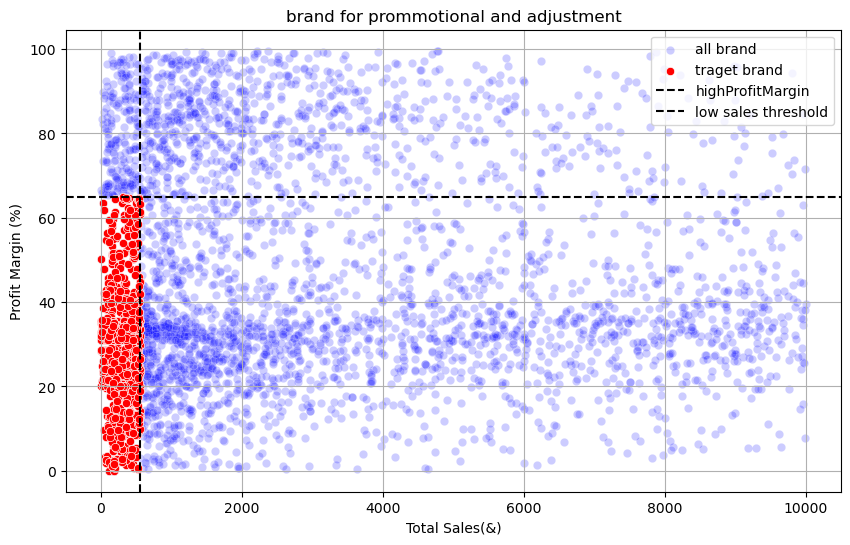

In [23]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=brand_performance,x='TotalSalesDollars',y='Profit_margin',color="blue",label="all brand",alpha=0.2)
sns.scatterplot(data=target_brand,x='TotalSalesDollars',y='Profit_margin',color="red",label="traget brand")
plt.axhline(high_profit_margin,linestyle="--",color="black",label='highProfitMargin')
plt.axvline(low_sales_threshold,linestyle="--",color="black",label='low sales threshold')

plt.xlabel("Total Sales(&)")
plt.ylabel("Profit Margin (%)")
plt.title("brand for prommotional and adjustment")
plt.legend()
plt.grid(True)
plt.show()

which and brands demonstrate the highest sales performance

In [24]:
def format_dollars(values):
    if(values)>1_000_000:
        return f"{values/1_000_000:.2f}M"
    elif(values>1_000):
        return f"{values/1_000:.2f}K"
    else:
        return str(values)

In [25]:
top_vendor=df.groupby("VendorName")["TotalSalesDollars"].sum().nlargest(10)
top_brand=df.groupby("Description")["TotalSalesDollars"].sum().nlargest(10)
top_vendor.apply(lambda x:format_dollars(x))

VendorName
DIAGEO NORTH AMERICA INC      67.99M
MARTIGNETTI COMPANIES         39.33M
PERNOD RICARD USA             32.06M
JIM BEAM BRANDS COMPANY       31.42M
BACARDI USA INC               24.85M
CONSTELLATION BRANDS INC      24.22M
E & J GALLO WINERY            18.40M
BROWN-FORMAN CORP             18.25M
ULTRA BEVERAGE COMPANY LLP    16.50M
M S WALKER INC                14.71M
Name: TotalSalesDollars, dtype: object

In [26]:
top_brand.apply(lambda x:format_dollars(x))

Description
Jack Daniels No 7 Black    7.96M
Tito's Handmade Vodka      7.40M
Grey Goose Vodka           7.21M
Capt Morgan Spiced Rum     6.36M
Absolut 80 Proof           6.24M
Jameson Irish Whiskey      5.72M
Ketel One Vodka            5.07M
Baileys Irish Cream        4.15M
Kahlua                     3.60M
Tanqueray                  3.46M
Name: TotalSalesDollars, dtype: object

top 10 vendors by sales
top 10 brands by sales


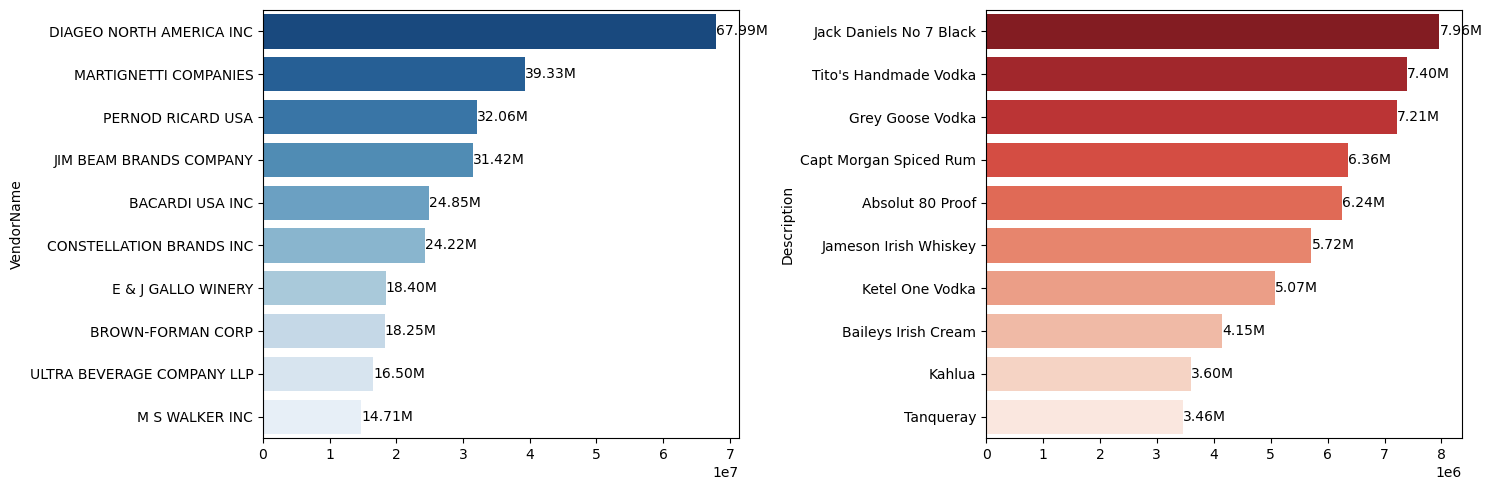

In [27]:
plt.figure(figsize=(15,5))

# plot for top vendor
plt.subplot(1,2,1)
ax1=sns.barplot(y=top_vendor.index,x=top_vendor.values,palette="Blues_r")
print("top 10 vendors by sales")

for bar in ax1.patches:
    ax1.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        format_dollars(bar.get_width()),
        ha='left',
        va='center',
        fontsize=10,
        color='black'
    )
             

# plot for top brand
plt.subplot(1,2,2)
ax2=sns.barplot(
    y=top_brand.index.astype(str),
    x=top_brand.values,
    palette="Reds_r"
)
print("top 10 brands by sales")

for bar in ax2.patches:
    ax2.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        format_dollars(bar.get_width()),
        ha='left',
        va='center',
        fontsize=10,
        color='black'
    )

plt.tight_layout()
plt.show()

### which vendor contribute the most purchase dollars ?

In [28]:
vendor_performance=df.groupby('VendorName').agg({
    'TotalPurchaseDollars':'sum',
    'Gross_profit':'sum',
    'TotalSalesDollars':'sum'}).reset_index()
top_performance = (
    vendor_performance
    .sort_values('TotalPurchaseDollars', ascending=False)
    .head(10)
)
print(len(top_performance))

10


In [29]:
top_performance['purchase_contribution%']=top_performance['TotalPurchaseDollars']/vendor_performance['TotalPurchaseDollars'].sum()*100
# top_performance

print(
    f"Total procurement dependent on top 10 vendors: "
    f"{top_performance['purchase_contribution%'].sum():.2f}%"
)

Total procurement dependent on top 10 vendors: 65.69%


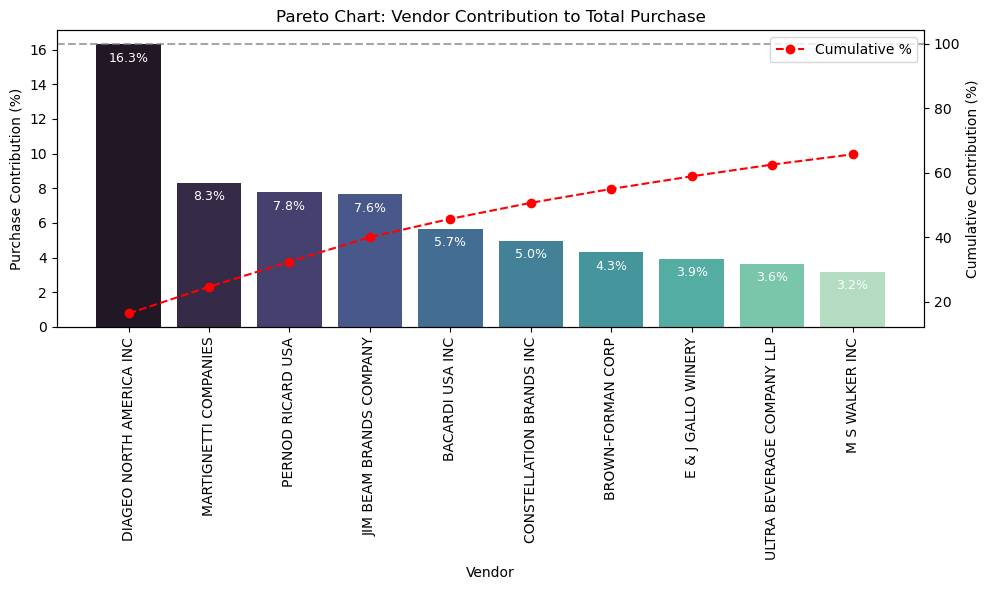

In [30]:
# Calculate contribution percentage
vendor_performance['purchase_contribution%'] = (
    vendor_performance['TotalPurchaseDollars']
    / vendor_performance['TotalPurchaseDollars'].sum()
    * 100
)

# Calculate cumulative percentage
top_performance['cumulative_contribution%'] = (
    top_performance['purchase_contribution%'].cumsum()
)

# Create figure and axes
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar chart
sns.barplot(
    x='VendorName',
    y='purchase_contribution%',
    data=top_performance,
    palette='mako',
    ax=ax1
)

# Add labels on bars
for i, value in enumerate(top_performance['purchase_contribution%']):
    ax1.text(
        i,
        value - 1,
        f'{value:.1f}%',
        ha='center',
        color='white',
        fontsize=9
    )

# Secondary axis for cumulative %
ax2 = ax1.twinx()

ax2.plot(
    top_performance['VendorName'],
    top_performance['cumulative_contribution%'],
    color='red',
    marker='o',
    linestyle='dashed',
    label='Cumulative %'
)

# Formatting
ax1.set_xticklabels(top_performance['VendorName'],rotation=90)

plt.tight_layout()  # prevents labels from getting cut off
ax1.set_ylabel('Purchase Contribution (%)')
ax2.set_ylabel('Cumulative Contribution (%)')
ax1.set_xlabel('Vendor')
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchase')

ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

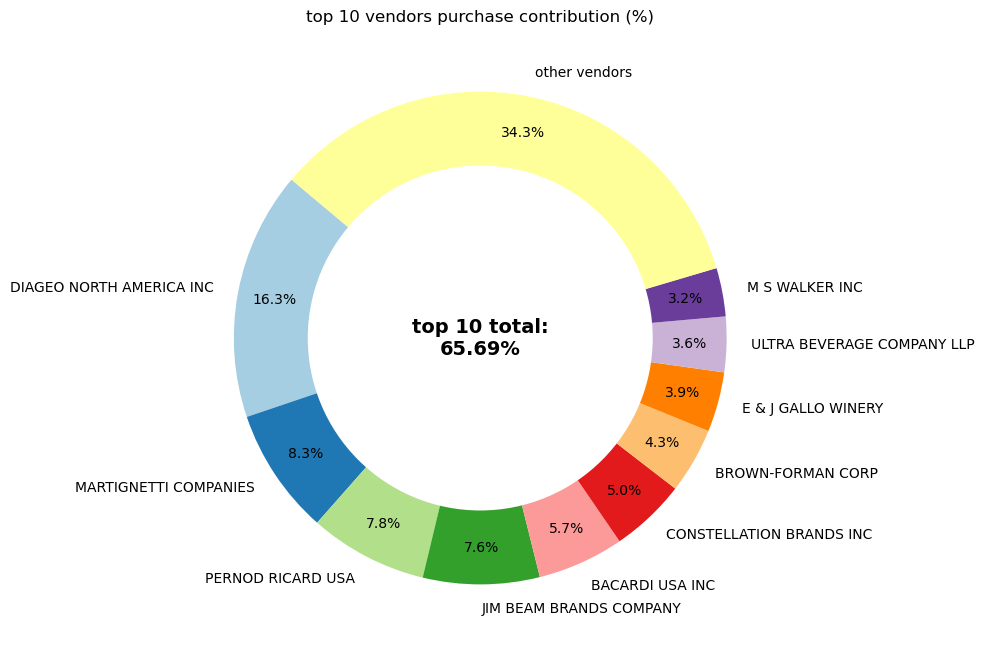

In [31]:
vendors=list(top_performance['VendorName'].values)

purchase_contributions=list(top_performance['purchase_contribution%'].values)

total_contributions=sum(purchase_contributions)

remaining_contribution=100-total_contributions

# append "other vendors" categories
vendors.append('other vendors')
purchase_contributions.append(remaining_contribution)

# donut chart
fig,ax=plt.subplots(figsize=(8,8))
wedges,texts,autotexts=ax.pie(purchase_contributions,labels=vendors,autopct='%1.1f%%',startangle=140,pctdistance=0.85,colors=plt.cm.Paired.colors)

# draw a white circle in center to create "donut effect"

center_circle=plt.Circle((0,0),0.70,fc="White")
fig.gca().add_artist(center_circle)

# add total contribution annotation in the center

plt.text(0,0,f"top 10 total:\n{total_contributions:.2f}%",fontsize=14,fontweight='bold',ha='center',va='center')

plt.title("top 10 vendors purchase contribution (%)")

plt.show()


 Does purchasing in bulk reduce the purchase price, and what optimal purchase volume for cost saving?

In [32]:
df['unitPurchasePrice']=df['TotalPurchaseDollars']/df['TotalPurchaseQuantity'] 
df['unitPurchasePrice']

0       26.27
1       23.19
2       18.24
3       16.17
4       21.89
        ...  
8559     1.32
8560     0.39
8561     0.74
8562     1.47
8563     0.71
Name: unitPurchasePrice, Length: 8564, dtype: float64

In [33]:
# devide it into 3 parts on bases of their size
df['OrderSize']=pd.qcut(df['TotalPurchaseQuantity'],q=3,labels=["small","medium","large"])
df[['OrderSize','TotalPurchaseQuantity']]

,OrderSize,TotalPurchaseQuantity
0,large,145080
1,large,164038
2,large,187407
3,large,201682
4,large,138109
...,...,...
8559,small,2
8560,small,6
8561,small,2
8562,small,1


In [34]:
df.groupby('OrderSize')[['unitPurchasePrice']].mean()

,unitPurchasePrice
OrderSize,
small,39.068186
medium,15.486414
large,10.777625


### which vendor have low inventory turnover,indicating excess stock and slow moving products

In [35]:
df[df['StockTurnOver']<1].groupby('VendorName')[['StockTurnOver']].mean().sort_values(by='StockTurnOver')

,StockTurnOver
VendorName,
FLAVOR ESSENCE INC,0.016949
DUGGANS DISTILLED PRODUCTS,0.230769
ATLANTIC IMPORTING COMPANY,0.295581
MOONLIGHT MEADERY,0.295652
CAPSTONE INTERNATIONAL,0.307692
...,...
ZORVINO VINEYARDS,0.976005
CANDIA VINEYARDS,0.977585
INCREDIBREW INC,0.979798


### How mich capital is locked in unsold inventory per vendor,and which vendors contribute the most to it?

In [36]:
df['UnsoldInventoryValue']=(df['TotalPurchaseQuantity']-df['TotalSalesQuantity'])*df['PurchasePrice']
print('Total unsold Capital:',format_dollars(df["UnsoldInventoryValue"].sum()))

Total unsold Capital: 2.71M


In [37]:
# aggregate capital locked capital
inventory_value_per_vendor=df.groupby("VendorName")["UnsoldInventoryValue"].sum().reset_index()

# sort vendors with the highest locked capital

inventory_value_per_vendor=inventory_value_per_vendor.sort_values(by="UnsoldInventoryValue",ascending=False)
inventory_value_per_vendor['UnsoldInventoryValue']=inventory_value_per_vendor['UnsoldInventoryValue'].apply(format_dollars)
inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
25,DIAGEO NORTH AMERICA INC,722.21K
46,JIM BEAM BRANDS COMPANY,554.67K
68,PERNOD RICARD USA,470.63K
116,WILLIAM GRANT & SONS INC,401.96K
30,E & J GALLO WINERY,228.28K
79,SAZERAC CO INC,198.44K
11,BROWN-FORMAN CORP,177.73K
20,CONSTELLATION BRANDS INC,133.62K
61,MOET HENNESSY USA INC,126.48K
77,REMY COINTREAU USA INC,118.60K


### what is the 95% confidance interval for profit margins of top-performing and low performing vendors

In [38]:
top_threshold=df["TotalSalesDollars"].quantile(0.75)
low_threshold=df["TotalSalesDollars"].quantile(0.25)

In [39]:
top_vendors=df[df["TotalSalesDollars"]>=top_threshold]["Profit_margin"].dropna()
low_vendors=df[df["TotalSalesDollars"]<=low_threshold]["Profit_margin"].dropna()


In [40]:
top_vendors

0       25.297693
1       21.062810
2       24.675786
3       27.139908
4       28.412764
          ...    
3523    79.684817
3681    85.782102
4751    93.085860
4920    95.012530
5050    94.271857
Name: Profit_margin, Length: 2141, dtype: float64

In [48]:
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data))
    
    t_critical = stats.t.ppf(
        (1 + confidence) / 2,
        df=len(data) - 1
    )
    
    margin_of_error = t_critical * std_err
    
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

Top vendors 95% CI: (31.61, 30.74), Mean: 31.18
Low vendors 95% CI: (42.64, 40.50), Mean: 41.57


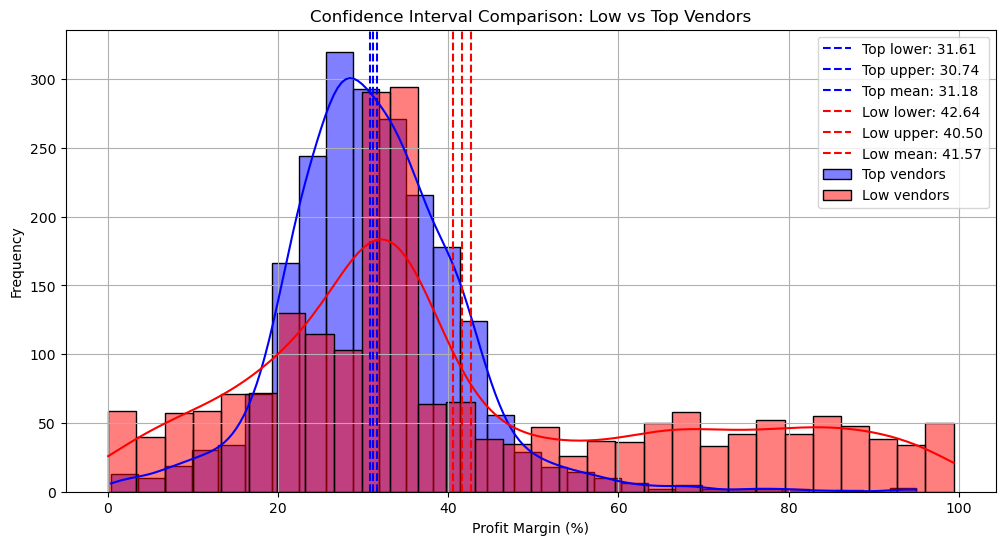

In [51]:
top_mean, top_upper, top_lower = confidence_interval(top_vendors)
low_mean, low_upper, low_lower = confidence_interval(low_vendors)

print(f"Top vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

plt.figure(figsize=(12, 6))

# Top vendors
sns.histplot(
    top_vendors,
    kde=True,
    color="blue",
    bins=30,
    alpha=0.5,
    label="Top vendors"
)

plt.axvline(top_lower, color="blue", linestyle="--",
            label=f"Top lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--",
            label=f"Top upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="--",
            label=f"Top mean: {top_mean:.2f}")


# Low vendors
sns.histplot(
    low_vendors,
    kde=True,
    color="red",
    bins=30,
    alpha=0.5,
    label="Low vendors"
)

plt.axvline(low_lower, color="red", linestyle="--",
            label=f"Low lower: {low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--",
            label=f"Low upper: {low_upper:.2f}")
plt.axvline(low_mean, color="red", linestyle="--",
            label=f"Low mean: {low_mean:.2f}")

plt.title("Confidence Interval Comparison: Low vs Top Vendors")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()